# Sepsis Model Evaluation

Loads the **already-trained** model (`artifacts/model_bundle.joblib`, produced by `03_train_model.py`) and lets you compute/compare different accuracy scores without retraining anything.

Run cells top to bottom.

In [1]:
import sys, json
from pathlib import Path

# Make sure config.py / sepsis_utils.py (in this same folder) are importable
PIPELINE_DIR = Path.cwd() if (Path.cwd() / "config.py").exists() else Path("/Users/prathosh/Desktop/DigitalTwins/sepsis_pipeline")
sys.path.insert(0, str(PIPELINE_DIR))

import numpy as np
import pandas as pd
from joblib import load
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

import config
import sepsis_utils

pd.set_option("display.max_rows", 50)

## 1. Load the pre-trained model

`model_bundle.joblib` contains the trained LightGBM model, the exact list/order of feature columns it was trained on, and the decision threshold chosen on the validation set.

In [2]:
bundle = load(config.MODEL_BUNDLE_PATH)
model = bundle["model"]
feature_names = bundle["feature_names"]
default_threshold = bundle["threshold"]

print(f"Loaded model with {len(feature_names)} features.")
print(f"Default decision threshold (chosen on validation set): {default_threshold:.4f}")

Loaded model with 214 features.
Default decision threshold (chosen on validation set): 0.0000


## 2. Load the test set

Same 10% held-out test split used when the model was originally trained (patient IDs saved in `artifacts/test_patient_ids.json`, so this is guaranteed to be data the model never saw).

In [3]:
features = pd.read_parquet(config.FEATURES_PARQUET)
features = sepsis_utils.add_row_utilities(features)  # adds row_u1/row_u0 needed for the utility score

test_ids = set(json.loads(config.TEST_IDS_PATH.read_text()))
test_df = features[features["patient_id"].isin(test_ids)].reset_index(drop=True)

X_test = test_df[feature_names]
y_test = test_df[config.LABEL_COL].to_numpy()
scores = model.predict(X_test)

print(f"Test set: {len(test_df):,} rows across {test_df['patient_id'].nunique():,} patients.")

Test set: 156,033 rows across 4,034 patients.


## 3. Metrics at the model's default threshold

In [4]:
metrics = sepsis_utils.evaluate_predictions(
    y_test, scores, test_df["row_u1"].to_numpy(), test_df["row_u0"].to_numpy(), default_threshold
)

pd.DataFrame([{
    "AUROC": metrics["auroc"],
    "AUPRC": metrics["auprc"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "F1": metrics["f1"],
    "Lift@10%": metrics["lift_at_10pct"],
    "Utility": metrics["utility"],
}], index=["test set"]).round(4)

,AUROC,AUPRC,Precision,Recall,F1,Lift@10%,Utility
test set,0.8458,0.1224,0.0691,0.7049,0.1259,5.5605,0.4382


## 4. Confusion matrix

In [5]:
cm = metrics["confusion_matrix"]
pd.DataFrame(
    [[cm["tp"], cm["fn"]], [cm["fp"], cm["tn"]]],
    index=["Actually sepsis", "Actually not sepsis"],
    columns=["Predicted: risk", "Predicted: no risk"],
)

,Predicted: risk,Predicted: no risk
Actually sepsis,1961,821
Actually not sepsis,26420,126831


## 5. Try different thresholds

Lower threshold -> catches more sepsis (higher recall) but more false alarms.
Higher threshold -> fewer false alarms but misses more sepsis.
Edit `candidate_thresholds` below to try your own values.

In [6]:
candidate_thresholds = [-0.10, -0.05, 0.00, default_threshold, 0.05, 0.10, 0.20]

rows = []
for thr in sorted(set(candidate_thresholds)):
    m = sepsis_utils.evaluate_predictions(
        y_test, scores, test_df["row_u1"].to_numpy(), test_df["row_u0"].to_numpy(), thr
    )
    rows.append({
        "threshold": round(thr, 4),
        "AUROC": m["auroc"],
        "AUPRC": m["auprc"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "Lift@10%": m["lift_at_10pct"],
        "Utility": m["utility"],
        "is_default": thr == default_threshold,
    })
pd.DataFrame(rows).round(4)

,threshold,AUROC,AUPRC,Precision,Recall,F1,Lift@10%,Utility,is_default
0,-0.10,0.8458,0.1224,0.0178,1.0000,0.0350,5.5605,-0.6161,False
1,-0.05,0.8458,0.1224,0.0217,0.9838,0.0425,5.5605,-0.3139,False
2,0.00,0.8458,0.1224,0.0691,0.7049,0.1259,5.5605,0.4382,False
3,0.00,0.8458,0.1224,0.0691,0.7049,0.1259,5.5605,0.4382,True
4,0.05,0.8458,0.1224,0.1157,0.4673,0.1854,5.5605,0.3738,False
5,0.10,0.8458,0.1224,0.1598,0.3537,0.2202,5.5605,0.3073,False
6,0.20,0.8458,0.1224,0.2033,0.1880,0.1953,5.5605,0.1725,False


## 6. Per-hospital breakdown

Checks whether the model generalizes evenly across the two source hospitals (A and B).

In [7]:
rows = []
for hosp in ["A", "B"]:
    mask = (test_df["hospital"] == hosp).to_numpy()
    m = sepsis_utils.evaluate_predictions(
        y_test[mask], scores[mask],
        test_df.loc[mask, "row_u1"].to_numpy(), test_df.loc[mask, "row_u0"].to_numpy(),
        default_threshold,
    )
    rows.append({
        "hospital": hosp,
        "AUROC": m["auroc"],
        "AUPRC": m["auprc"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "Lift@10%": m["lift_at_10pct"],
        "Utility": m["utility"],
    })
pd.DataFrame(rows).round(4)

,hospital,AUROC,AUPRC,Precision,Recall,F1,Lift@10%,Utility
0,A,0.8308,0.1179,0.0699,0.7344,0.1276,5.3645,0.4567
1,B,0.8608,0.1427,0.0678,0.6576,0.1229,5.6220,0.4075


## 7. ROC and Precision-Recall curves

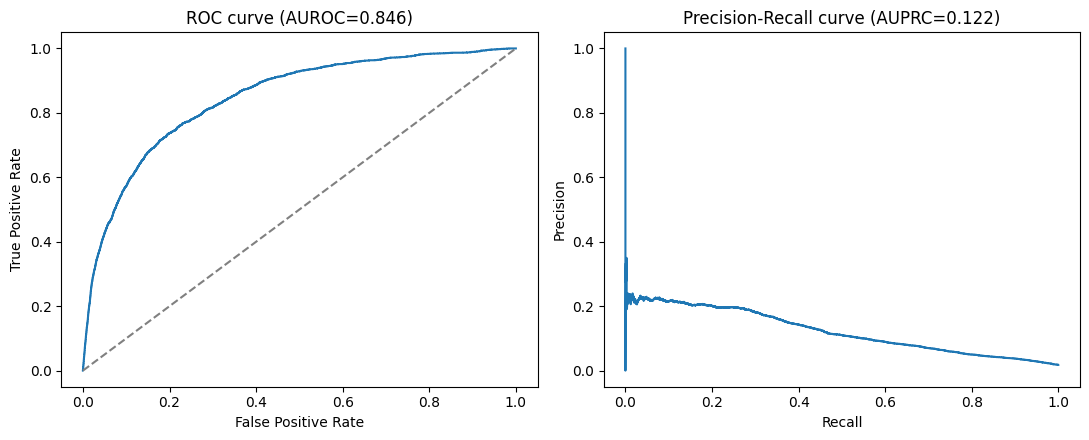

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(y_test, scores)
axes[0].plot(fpr, tpr)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC curve (AUROC={metrics['auroc']:.3f})")

prec, rec, _ = precision_recall_curve(y_test, scores)
axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall curve (AUPRC={metrics['auprc']:.3f})")

plt.tight_layout()
plt.show()

## 8. Train / validation / test comparison

A quick overfitting check -- train-set scores are expected to be a bit higher than val/test.

In [9]:
train_ids = set(json.loads(config.TRAIN_IDS_PATH.read_text()))
val_ids = set(json.loads(config.VAL_IDS_PATH.read_text()))

rows = []
for name, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    split_df = features[features["patient_id"].isin(ids)]
    X = split_df[feature_names]
    y = split_df[config.LABEL_COL].to_numpy()
    s = model.predict(X)
    m = sepsis_utils.evaluate_predictions(
        y, s, split_df["row_u1"].to_numpy(), split_df["row_u0"].to_numpy(), default_threshold
    )
    rows.append({
        "split": name,
        "AUROC": m["auroc"],
        "AUPRC": m["auprc"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "Lift@10%": m["lift_at_10pct"],
        "Utility": m["utility"],
    })
pd.DataFrame(rows).round(4)

,split,AUROC,AUPRC,Precision,Recall,F1,Lift@10%,Utility
0,train,0.8816,0.1959,0.0747,0.7696,0.1362,6.0760,0.4988
1,val,0.8443,0.1346,0.0683,0.7097,0.1247,5.4091,0.4354
2,test,0.8458,0.1224,0.0691,0.7049,0.1259,5.5605,0.4382


## 9. Confusion matrices — train / validation / test

Same decision threshold applied to all three splits, so they're directly comparable.

In [10]:
split_cms = {}
for name, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    split_df = features[features["patient_id"].isin(ids)]
    X = split_df[feature_names]
    y = split_df[config.LABEL_COL].to_numpy()
    s = model.predict(X)
    m = sepsis_utils.evaluate_predictions(
        y, s, split_df["row_u1"].to_numpy(), split_df["row_u0"].to_numpy(), default_threshold
    )
    split_cms[name] = m["confusion_matrix"]

cm_table = pd.DataFrame(split_cms).T[["tp", "fn", "fp", "tn"]]
cm_table.columns = ["TP (correctly flagged sepsis)", "FN (missed sepsis)",
                     "FP (false alarm)", "TN (correctly no risk)"]
cm_table

,TP (correctly flagged sepsis),FN (missed sepsis),FP (false alarm),TN (correctly no risk)
train,17191,5146,212922,1005627
val,1985,812,27060,125434
test,1961,821,26420,126831


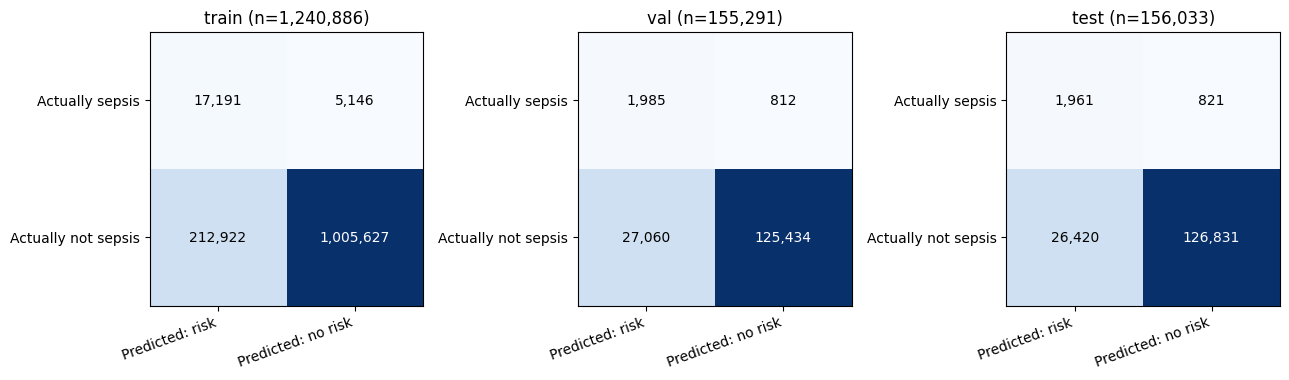

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, cm) in zip(axes, split_cms.items()):
    matrix = np.array([[cm["tp"], cm["fn"]], [cm["fp"], cm["tn"]]])
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted: risk", "Predicted: no risk"], rotation=20, ha="right")
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actually sepsis", "Actually not sepsis"])
    ax.set_title(f"{name} (n={matrix.sum():,})")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center",
                     color="white" if matrix[i, j] > matrix.max() / 2 else "black")
plt.tight_layout()
plt.show()

## 10. False-alarm penalty sensitivity sweep

What if false alarms cost more than −0.05? This does **not** retrain the model — it reuses the exact same trained model's scores, and only changes two things: (a) how harshly a false alarm is graded, and (b) which threshold that grading says is "optimal" (re-selected on the validation set each time, then reported on test, same as everywhere else in this notebook).

Raising the false-alarm penalty should push the optimal threshold up (more conservative), which should mean **fewer FP but likely fewer TP too** -- same underlying model, just a different operating point on its existing precision/recall tradeoff.

In [12]:
val_df = features[features["patient_id"].isin(val_ids)].reset_index(drop=True)
X_val = val_df[feature_names]
val_scores = model.predict(X_val)
print(f"Validation set: {len(val_df):,} rows across {val_df['patient_id'].nunique():,} patients.")

Validation set: 155,291 rows across 4,034 patients.


In [13]:
FP_PENALTIES = [-0.025, -0.05, -0.075, -0.1]
CURRENT_PENALTY = -0.05  # config.U_FP -- what the deployed model was actually trained/graded with

sweep_results = []
sweep_cms = {}
for u_fp in FP_PENALTIES:
    # Re-grade the SAME model scores under this false-alarm penalty: pick the
    # utility-optimal threshold on validation, then report on test (same
    # methodology as everywhere else in this notebook -- never pick the
    # threshold on the test set itself).
    val_u = sepsis_utils.add_row_utilities(
        val_df[["patient_id", "ICULOS", config.LABEL_COL]], u_fp=u_fp
    )
    best_threshold, best_val_utility, _ = sepsis_utils.threshold_grid_search(
        val_scores, val_u["row_u1"].to_numpy(), val_u["row_u0"].to_numpy()
    )

    test_u = sepsis_utils.add_row_utilities(
        test_df[["patient_id", "ICULOS", config.LABEL_COL]], u_fp=u_fp
    )
    m = sepsis_utils.evaluate_predictions(
        y_test, scores, test_u["row_u1"].to_numpy(), test_u["row_u0"].to_numpy(), best_threshold
    )

    sweep_results.append({
        "false_alarm_penalty": round(u_fp, 5),
        "threshold": round(best_threshold, 4),
        "AUROC": m["auroc"],
        "AUPRC": m["auprc"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "Lift@10%": m["lift_at_10pct"],
        "Utility": m["utility"],
        "is_current": bool(np.isclose(u_fp, CURRENT_PENALTY)),
    })
    sweep_cms[round(u_fp, 5)] = m["confusion_matrix"]

pd.DataFrame(sweep_results).round(4)

,false_alarm_penalty,threshold,AUROC,AUPRC,Precision,Recall,F1,Lift@10%,Utility,is_current
0,-0.025,-0.01,0.8458,0.1224,0.0591,0.7541,0.1095,5.5605,0.5861,False
1,-0.050,0.00,0.8458,0.1224,0.0691,0.7049,0.1259,5.5605,0.4382,True
2,-0.075,0.03,0.8458,0.1224,0.0984,0.5572,0.1673,5.5605,0.3465,False
3,-0.100,0.03,0.8458,0.1224,0.0984,0.5572,0.1673,5.5605,0.2742,False


In [14]:
cm_rows = []
for u_fp, cm in sweep_cms.items():
    cm_rows.append({
        "false_alarm_penalty": u_fp,
        "TP (correctly flagged sepsis)": cm["tp"],
        "FN (missed sepsis)": cm["fn"],
        "FP (false alarm)": cm["fp"],
        "TN (correctly no risk)": cm["tn"],
    })
pd.DataFrame(cm_rows).set_index("false_alarm_penalty")

,TP (correctly flagged sepsis),FN (missed sepsis),FP (false alarm),TN (correctly no risk)
false_alarm_penalty,,,,
-0.025,2098,684,33430,119821
-0.050,1961,821,26420,126831
-0.075,1550,1232,14197,139054
-0.100,1550,1232,14197,139054


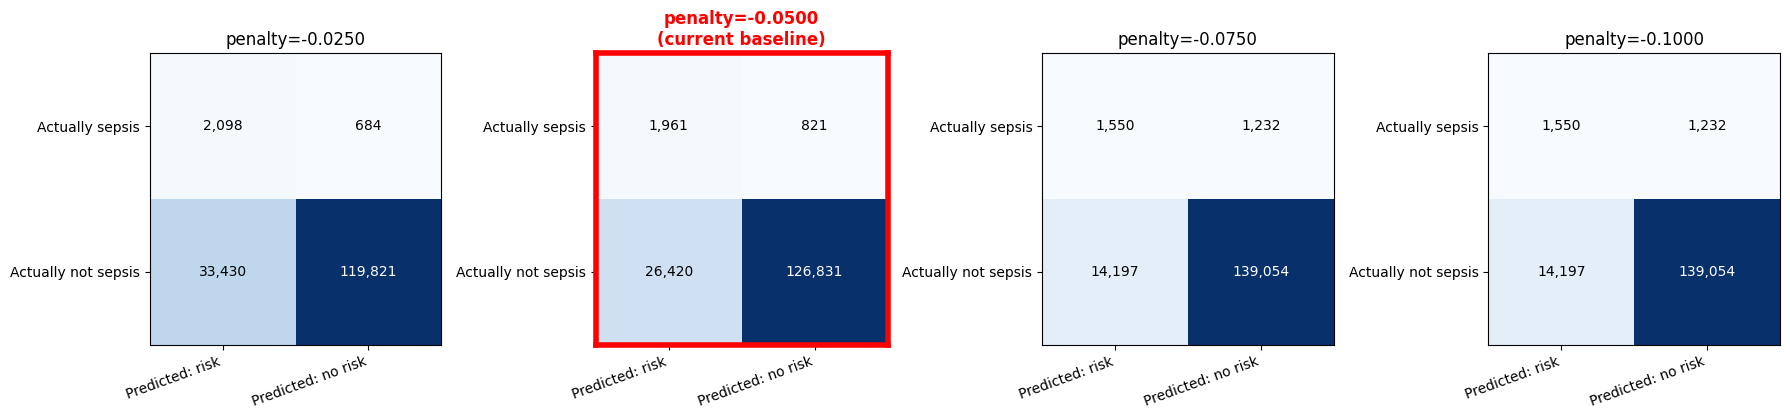

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (u_fp, cm) in zip(axes.ravel(), sweep_cms.items()):
    matrix = np.array([[cm["tp"], cm["fn"]], [cm["fp"], cm["tn"]]])
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted: risk", "Predicted: no risk"], rotation=20, ha="right")
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actually sepsis", "Actually not sepsis"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center",
                     color="white" if matrix[i, j] > matrix.max() / 2 else "black")

    is_current = np.isclose(u_fp, CURRENT_PENALTY)
    if is_current:
        ax.set_title(f"penalty={u_fp:.4f}\n(current baseline)", color="red", fontweight="bold")
        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(4)
    else:
        ax.set_title(f"penalty={u_fp:.4f}")

plt.tight_layout()
plt.show()

## 11. Reward/penalty grid search (model unchanged)

Sweeps `max_u_tp` (reward for a perfectly-timed catch), `min_u_fn` (penalty for a missed case), and `u_fp` (false-alarm penalty) — 27 combinations. **The model itself is never touched or retrained** — this reuses the exact same `scores`/`val_scores` computed in Section 2, and only changes (a) which threshold that combination says is optimal, and (b) how the resulting confusion matrix gets graded. Baseline = the values actually used to train the deployed model (`max_u_tp=1.0, min_u_fn=-2.0, u_fp=-0.05`).

In [16]:
MAX_U_TP_GRID = [0.5, 1.0, 1.5]
MIN_U_FN_GRID = [-1.0, -2.0, -3.0]
U_FP_GRID_2 = [-0.025, -0.05, -0.1]

reward_sweep_results = []
for max_u_tp in MAX_U_TP_GRID:
    for min_u_fn in MIN_U_FN_GRID:
        for u_fp in U_FP_GRID_2:
            # Same methodology as Section 10: threshold picked on validation, reported on
            # test. Model scores (`scores`, `val_scores`) are untouched throughout.
            val_u = sepsis_utils.add_row_utilities(
                val_df[["patient_id", "ICULOS", config.LABEL_COL]],
                u_fp=u_fp, max_u_tp=max_u_tp, min_u_fn=min_u_fn,
            )
            best_threshold, _, _ = sepsis_utils.threshold_grid_search(
                val_scores, val_u["row_u1"].to_numpy(), val_u["row_u0"].to_numpy()
            )

            test_u = sepsis_utils.add_row_utilities(
                test_df[["patient_id", "ICULOS", config.LABEL_COL]],
                u_fp=u_fp, max_u_tp=max_u_tp, min_u_fn=min_u_fn,
            )
            m = sepsis_utils.evaluate_predictions(
                y_test, scores, test_u["row_u1"].to_numpy(), test_u["row_u0"].to_numpy(), best_threshold
            )

            reward_sweep_results.append({
                "max_u_tp": max_u_tp,
                "min_u_fn": min_u_fn,
                "u_fp": u_fp,
                "threshold": round(best_threshold, 4),
                "Precision": m["precision"],
                "Recall": m["recall"],
                "F1": m["f1"],
                "Utility": m["utility"],
                "TP": m["confusion_matrix"]["tp"],
                "FN": m["confusion_matrix"]["fn"],
                "FP": m["confusion_matrix"]["fp"],
                "TN": m["confusion_matrix"]["tn"],
                "is_baseline": (max_u_tp, min_u_fn, u_fp) == (1.0, -2.0, -0.05),
            })

reward_sweep_df = pd.DataFrame(reward_sweep_results)

print(f"AUROC={metrics['auroc']:.4f}, AUPRC={metrics['auprc']:.4f}, Lift@10%={metrics['lift_at_10pct']:.4f} "
      "are IDENTICAL for every row below -- these depend only on the model's raw scores and the "
      "true labels, never on how rewards/penalties are defined. This sweep only ever changes "
      "which threshold gets picked and how the resulting confusion matrix gets graded.")
print("NOTE: 'Utility' is NOT comparable across different (max_u_tp, min_u_fn, u_fp) settings -- "
      "it's defined differently in each row (e.g. shrinking all penalties toward 0 trivially "
      "inflates it without the model improving at all). Precision/Recall/F1/confusion counts ARE "
      "comparable across rows.")

reward_sweep_df.sort_values("F1", ascending=False).round(4)

AUROC=0.8458, AUPRC=0.1224, Lift@10%=5.5605 are IDENTICAL for every row below -- these depend only on the model's raw scores and the true labels, never on how rewards/penalties are defined. This sweep only ever changes which threshold gets picked and how the resulting confusion matrix gets graded.
NOTE: 'Utility' is NOT comparable across different (max_u_tp, min_u_fn, u_fp) settings -- it's defined differently in each row (e.g. shrinking all penalties toward 0 trivially inflates it without the model improving at all). Precision/Recall/F1/confusion counts ARE comparable across rows.


,max_u_tp,min_u_fn,u_fp,threshold,Precision,Recall,F1,Utility,TP,FN,FP,TN,is_baseline
2,0.5,-1.0,-0.100,0.17,0.1955,0.2390,0.2151,0.1364,665,2117,2737,150514,False
11,1.0,-1.0,-0.100,0.08,0.1444,0.3918,0.2111,0.2028,1090,1692,6457,146794,False
5,0.5,-2.0,-0.100,0.06,0.1275,0.4446,0.1981,0.2439,1237,1545,8468,144783,False
20,1.5,-1.0,-0.100,0.06,0.1275,0.4446,0.1981,0.2445,1237,1545,8468,144783,False
23,1.5,-2.0,-0.100,0.03,0.0984,0.5572,0.1673,0.3174,1550,1232,14197,139054,False
8,0.5,-3.0,-0.100,0.03,0.0984,0.5572,0.1673,0.3112,1550,1232,14197,139054,False
10,1.0,-1.0,-0.050,0.03,0.0984,0.5572,0.1673,0.3474,1550,1232,14197,139054,False
17,1.0,-3.0,-0.100,0.03,0.0984,0.5572,0.1673,0.3459,1550,1232,14197,139054,False
1,0.5,-1.0,-0.050,0.03,0.0984,0.5572,0.1673,0.2742,1550,1232,14197,139054,False
14,1.0,-2.0,-0.100,0.03,0.0984,0.5572,0.1673,0.2742,1550,1232,14197,139054,False


In [17]:
print("Best by F1:")
print(reward_sweep_df.sort_values("F1", ascending=False).iloc[0][
    ["max_u_tp", "min_u_fn", "u_fp", "threshold", "Precision", "Recall", "F1", "Utility"]
])
print("\nBest by Recall:")
print(reward_sweep_df.sort_values("Recall", ascending=False).iloc[0][
    ["max_u_tp", "min_u_fn", "u_fp", "threshold", "Precision", "Recall", "F1", "Utility"]
])
print("\nCurrent baseline (max_u_tp=1.0, min_u_fn=-2.0, u_fp=-0.05):")
print(reward_sweep_df[reward_sweep_df["is_baseline"]].iloc[0][
    ["max_u_tp", "min_u_fn", "u_fp", "threshold", "Precision", "Recall", "F1", "Utility"]
])

Best by F1:
max_u_tp          0.5
min_u_fn         -1.0
u_fp             -0.1
threshold        0.17
Precision    0.195473
Recall       0.239037
F1           0.215071
Utility      0.136395
Name: 2, dtype: object

Best by Recall:
max_u_tp          1.5
min_u_fn         -3.0
u_fp           -0.025
threshold       -0.03
Precision    0.039384
Recall       0.880302
F1           0.075394
Utility      0.676604
Name: 24, dtype: object

Current baseline (max_u_tp=1.0, min_u_fn=-2.0, u_fp=-0.05):
max_u_tp          1.0
min_u_fn         -2.0
u_fp            -0.05
threshold         0.0
Precision    0.069096
Recall       0.704889
F1           0.125854
Utility      0.438153
Name: 13, dtype: object


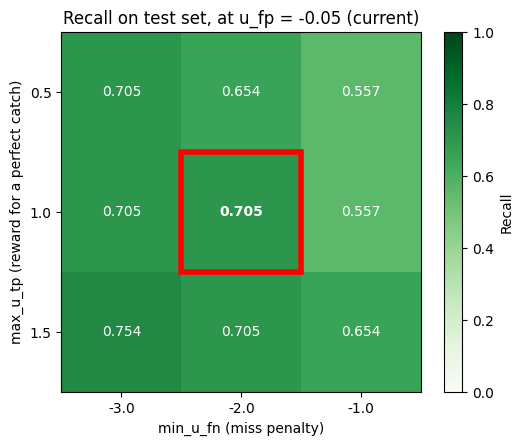

In [18]:
baseline_slice = reward_sweep_df[reward_sweep_df["u_fp"] == -0.05]
pivot = baseline_slice.pivot(index="max_u_tp", columns="min_u_fn", values="Recall")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(pivot.values, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("min_u_fn (miss penalty)")
ax.set_ylabel("max_u_tp (reward for a perfect catch)")
ax.set_title("Recall on test set, at u_fp = -0.05 (current)")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        is_baseline = (pivot.index[i] == 1.0) and (pivot.columns[j] == -2.0)
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                 color="white" if val > 0.5 else "black",
                 fontweight="bold" if is_baseline else "normal")
        if is_baseline:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                        edgecolor="red", linewidth=4))
plt.colorbar(im, label="Recall")
plt.tight_layout()
plt.show()